In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from dotenv import load_dotenv
from sqlalchemy import false

sns.set_theme(style="whitegrid")
palette = ["#4e79a7", "#f28e2b"]

sys.path.append(os.path.abspath(os.path.join('..')))
from utils.db_handler import DatabaseHandler

In [11]:
# Load environment variables
env_path = os.path.join('..', '.env')
if not os.path.exists(env_path):
    env_path = os.path.join('..', '.env.example')
load_dotenv(env_path)

# Build database URL for local environment (using localhost instead of docker service name)
db_user = os.getenv('POSTGRES_USER')
db_password = os.getenv('POSTGRES_PASSWORD')
db_name = os.getenv('POSTGRES_DB')
db_port = os.getenv('POSTGRES_PORT')
db_host = 'localhost'

database_url = f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"

# Initialize database connection
db = DatabaseHandler(database_url=database_url)

In [12]:
# Load the dataset
df = pd.DataFrame(db.get_all_jobs())

# 1. First insights

In [13]:
print("--- INITIAL DATA INFO ---")
df.info()

--- INITIAL DATA INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 3826 entries, 0 to 3825
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID                3826 non-null   str           
 1   Stanowisko        3826 non-null   str           
 2   Firma             3826 non-null   str           
 3   Poziom            3826 non-null   str           
 4   Kategoria         2945 non-null   str           
 5   Technologie       3826 non-null   str           
 6   Lokalizacja       3824 non-null   str           
 7   Wynagrodzenie Od  1017 non-null   float64       
 8   Wynagrodzenie Do  1014 non-null   float64       
 9   Waluta            3190 non-null   str           
 10  Utworzono         3826 non-null   datetime64[us]
 11  Zaktualizowano    2945 non-null   datetime64[us]
 12  Scraped At        3826 non-null   datetime64[us]
 13  Source            3826 non-null   str           
dtypes: dateti

In [14]:
print("\n--- MISSING VALUES ---")
print(df.isnull().sum())


--- MISSING VALUES ---
ID                     0
Stanowisko             0
Firma                  0
Poziom                 0
Kategoria            881
Technologie            0
Lokalizacja            2
Wynagrodzenie Od    2809
Wynagrodzenie Do    2812
Waluta               636
Utworzono              0
Zaktualizowano       881
Scraped At             0
Source                 0
dtype: int64


In [15]:
print("\n--- DUPLICATES ---")
print(f"Number of exact duplicate rows: {df.duplicated().sum()}")
# Check duplicates by ID
if 'ID' in df.columns:
    print(f"Number of duplicate IDs: {df.duplicated(subset=['ID']).sum()}")


--- DUPLICATES ---
Number of exact duplicate rows: 0
Number of duplicate IDs: 0


# 2. Handle missing values

## 2.1 Currency
Based on the sources from which the data was retrieved, we assume that the default currency is PLN. 

In [16]:
df["Waluta"] = df["Waluta"].fillna("PLN")

## 2.2 Category
Our primary focus is on technology. The “category” column does not add much value to the analysis. Therefore, it will be excluded from further exploratory analysis.

In [17]:
df.drop(columns=["Kategoria"], inplace=True, errors='ignore')
df.columns.tolist()

['ID',
 'Stanowisko',
 'Firma',
 'Poziom',
 'Technologie',
 'Lokalizacja',
 'Wynagrodzenie Od',
 'Wynagrodzenie Do',
 'Waluta',
 'Utworzono',
 'Zaktualizowano',
 'Scraped At',
 'Source']

## 2.3 Salaries
Before we proceed with further analysis, let's begin by presenting salaries on charts.

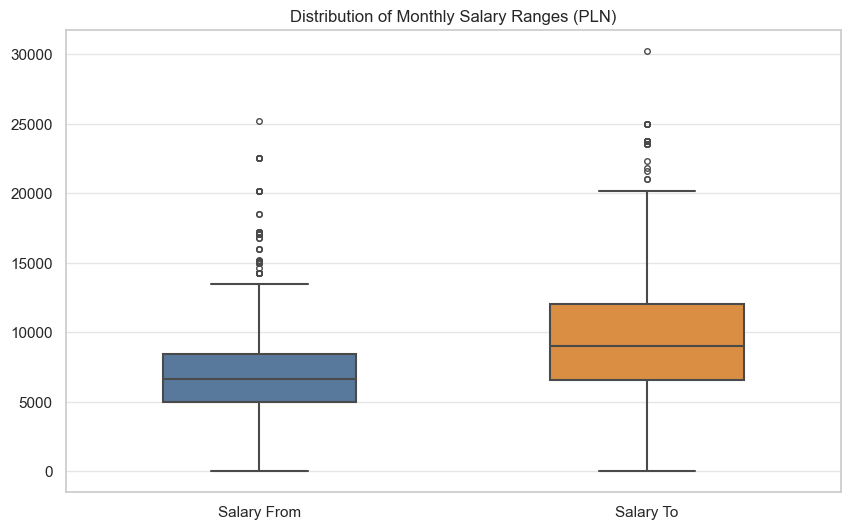

In [18]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df[["Wynagrodzenie Od", "Wynagrodzenie Do"]], 
    palette=palette,
    width=0.5,
    linewidth=1.5,
    fliersize=4 # Size of outlier points
)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Salary From", "Salary To"])
plt.title("Distribution of Monthly Salary Ranges (PLN)")
plt.show()

The chart shows values below 1,000, which means that hourly rates may be listed. Let’s convert them to monthly rates, assuming that a month has 168 working hours

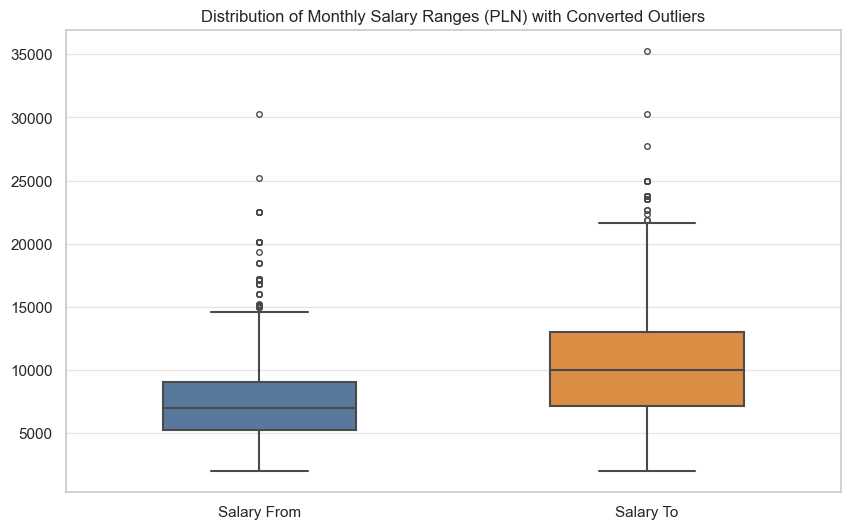

In [19]:
# Convert outliers to monthly salary
df.loc[df["Wynagrodzenie Od"] < 1000, "Wynagrodzenie Od"] = df.loc[df["Wynagrodzenie Od"] < 1000, "Wynagrodzenie Od"] * 168
df.loc[df["Wynagrodzenie Do"] < 1000, "Wynagrodzenie Do"] = df.loc[df["Wynagrodzenie Do"] < 1000, "Wynagrodzenie Do"] * 168

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df[["Wynagrodzenie Od", "Wynagrodzenie Do"]], 
    palette=palette,
    width=0.5,
    linewidth=1.5,
    fliersize=4 # Size of outlier points
)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Salary From", "Salary To"])
plt.title("Distribution of Monthly Salary Ranges (PLN) with Converted Outliers")
plt.show()

Let’s plot the adjusted salaries on a graph to analyze the distribution of salaries

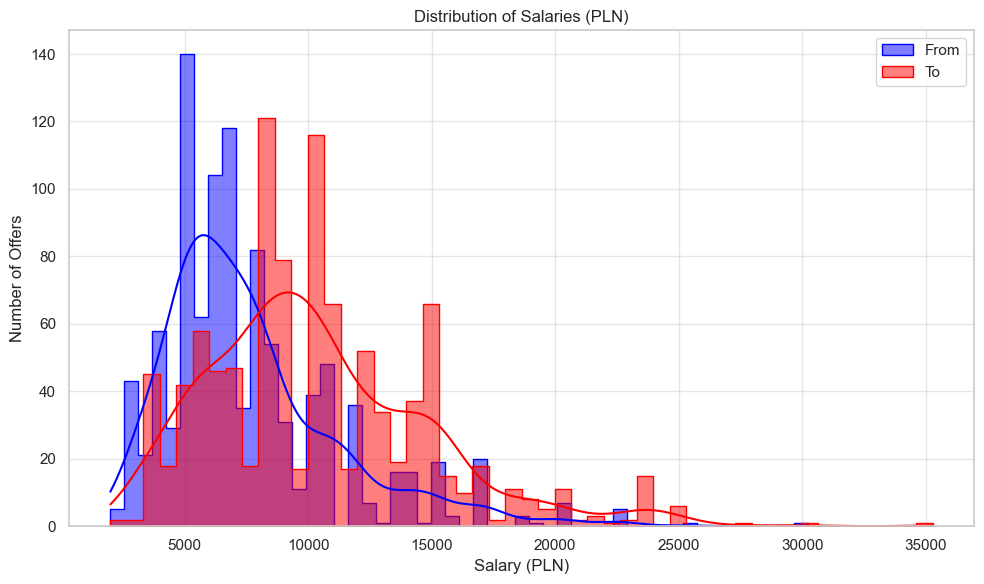

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Wynagrodzenie Od', bins=50, kde=True, color='blue', label='From', element="step")
sns.histplot(data=df, x='Wynagrodzenie Do', bins=50, kde=True, color='red', alpha=0.5, label='To', element="step")
plt.title("Distribution of Salaries (PLN)")
plt.xlabel("Salary (PLN)")
plt.ylabel("Number of Offers")
plt.legend()
plt.tight_layout()
plt.show()

## 2.4 Technologies
Currently, the technologies are displayed in a single column as a list of values. To make it easier to analyze the data, we will use the `exploded` function to convert the list into multiple columns

Before exploding: 49738 rows
After exploding: 174486 rows
Unique technologies: 1382
Top 20 technologies:
Technologie
Python        752
SQL           729
Java          428
JavaScript    319
Git           301
Linux         285
Jira          219
AI            192
Azure         187
C#            186
HTML          167
PHP           145
CSS           139
ETL           130
Windows       123
Docker        122
TypeScript    120
C++           105
MS Office     103
AWS            94
Name: count, dtype: int64


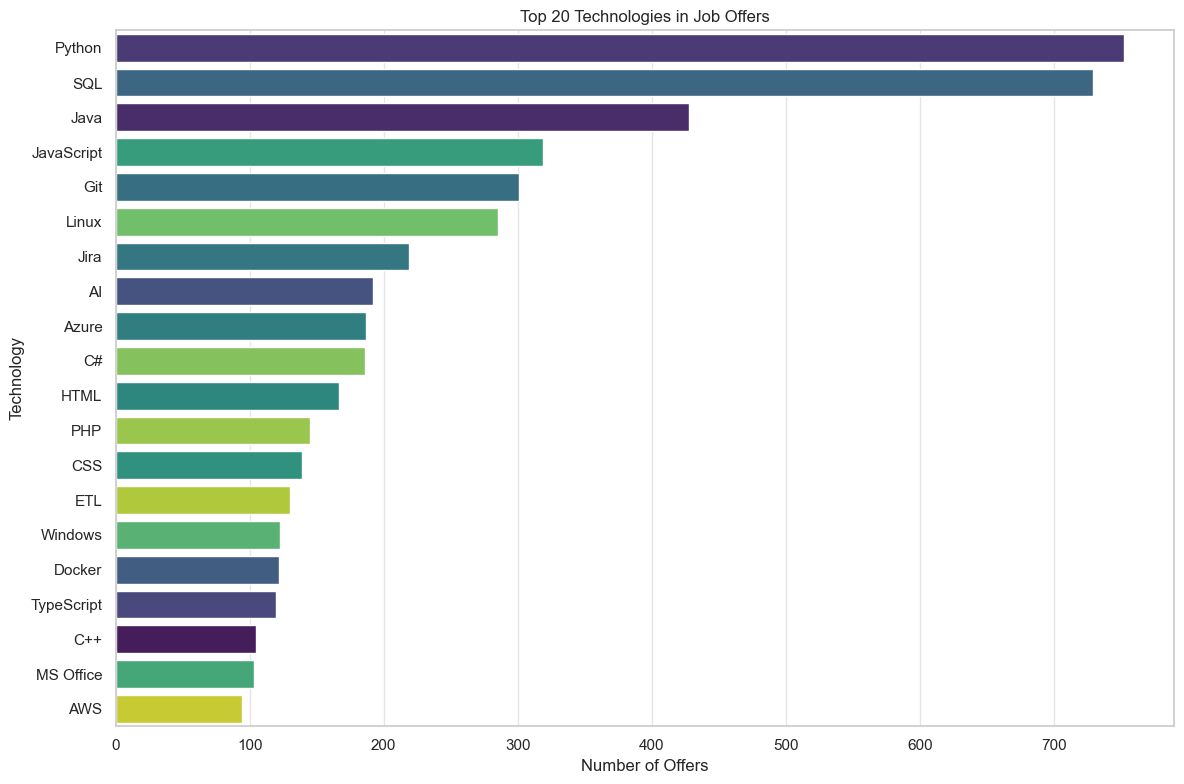

In [21]:
print(f"Before exploding: {df.size} rows")

df["Technologie"] = df["Technologie"].astype(str).str.split(',')
df = df.explode("Technologie")
df["Technologie"] = df["Technologie"].str.strip()
df = df[df["Technologie"] != "Brak danych"]

print(f"After exploding: {df.size} rows")

print(f"Unique technologies: {df['Technologie'].nunique()}")

top_20_techs = df["Technologie"].value_counts().head(20)
print(f"Top 20 technologies:\n{top_20_techs}")

plt.figure(figsize=(12, 8))
sns.countplot(data=df[df["Technologie"].isin(top_20_techs.index)], 
            y="Technologie",
            order=top_20_techs.index, 
            palette='viridis',
            legend=False,
            hue='Technologie')
plt.title("Top 20 Technologies in Job Offers")
plt.xlabel("Number of Offers")
plt.ylabel("Technology")
plt.tight_layout()
plt.show()


# 3.Find feature correlations

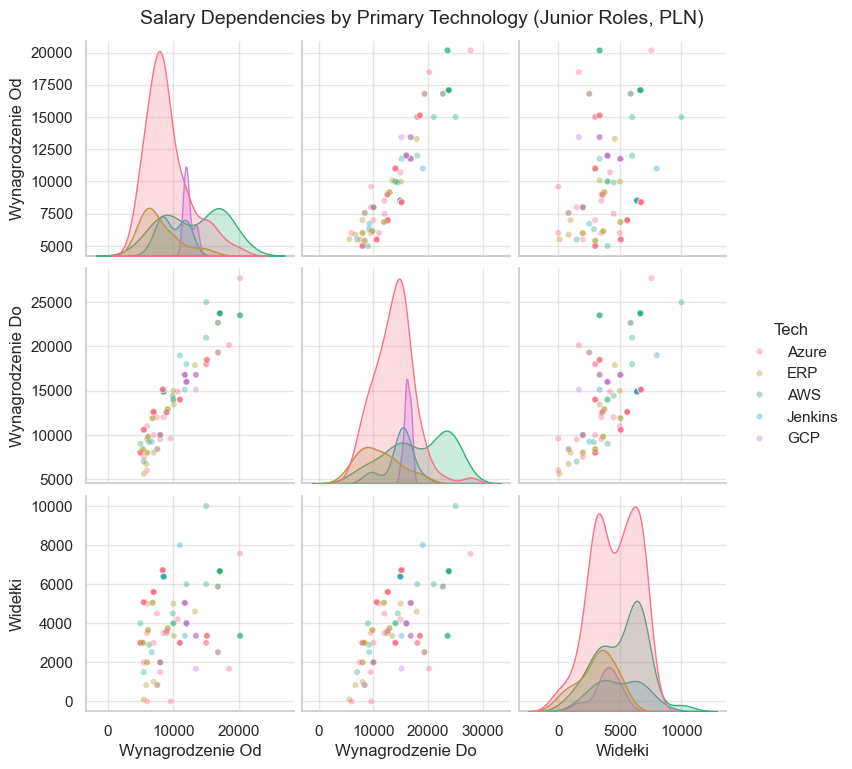

In [27]:
# Filter for a single currency to ensure salary comparisons are "apples-to-apples"
# Using .copy() avoids the SettingWithCopyWarning later on.
df_clean = df[df['Waluta'] == 'PLN'].copy()

# Define our target technologies for categorization
top_techs = ['AWS', 'GCP', 'Jenkins', 'Azure', 'ERP']

# Logic to extract the "primary" tech from a string (e.g., from "Python, AWS, Docker" -> "AWS")
def get_Tech(tech_string):
    if pd.isna(tech_string):
        return None
    for tech in top_techs:
        # Case-insensitive search to catch "aws" or "AWS"
        if tech.lower() in tech_string.lower():
            return tech
    return None

# Apply categorization to create a clean 'Tech' column for the plot legend
df_clean['Tech'] = df_clean['Technologie'].apply(get_Tech)

# Drop rows where we lack the essential data (Tech or Salary)
# This ensures the pairplot doesn't crash on NaN values.
df_plot = df_clean.dropna(subset=['Tech', 'Wynagrodzenie Od', 'Wynagrodzenie Do']).copy()

# Feature Engineering: Calculate the salary spread (Range/Widełki)
# Using .loc is the 2026 best practice for adding columns to sliced DataFrames.
df_plot.loc[:, 'Widełki'] = df_plot['Wynagrodzenie Do'] - df_plot['Wynagrodzenie Od']

# Configure and generate the Seaborn pairplot
# We visualize relationships between Min Salary, Max Salary, and the Range.
g = sns.pairplot(
    df_plot[['Wynagrodzenie Od', 'Wynagrodzenie Do', 'Widełki', 'Tech']],
    hue='Tech',              # Colors points based on technology
    palette='husl',          # A vibrant, balanced color palette
    diag_kind='kde',         # Kernel Density Estimate on the diagonal for distribution peaks
    plot_kws={
        'alpha': 0.4,        # Transparency helps see overlapping points in large datasets
        's': 20              # Point size (small enough to avoid a massive "blob")
    }
)

# Final aesthetic touches: adjust title position and display the plot
g.fig.suptitle('Salary Dependencies by Primary Technology (Junior Roles, PLN)', y=1.02, fontsize=14)
plt.show()

Since these findings represent **Junior** positions in 2026, the data reveals a fascinating landscape where "Junior" roles in Cloud technologies can sometimes command salaries that rival mid-level positions in other sectors.

### 1. The Entry Point: Where do Juniors start? (KDE Analysis)
Looking at the **Wynagrodzenie Od** (Starting Salary) density plots:
* **Azure (Pink):** Shows a very sharp, high peak around **8,000 – 10,000 PLN**. This indicates a high level of market standardization. If you apply for an Azure Junior role, this is your most likely starting point.
* **GCP (Purple):** Interestingly, the peak is shifted significantly to the right, landing around **15,000 PLN**. This suggests that Junior roles in Google Cloud are specialized and premium-priced compared to the competition.
* **AWS (Green):** Displays the widest "belly." While it starts low, the distribution is broad, meaning the definition of a "Junior" in AWS varies wildly—from entry-level support to high-end Junior DevOps.

### 2. Negotiation Room: The "Widełki" (Range) Insight
The **Widełki** (difference between Max and Min salary) column is a proxy for negotiation power:
* **High Flexibility (AWS & Azure):** These technologies show ranges extending up to **10,000 PLN**. For a Junior, this means your specific skills, certifications, or "vibes" during the interview can drastically swing your final offer.
* **The "Fixed" Market (ERP):** The beige clusters are concentrated at the bottom. In ERP, "Junior" often comes with a fixed budget and very little room for financial maneuvering.

### 3. The "Super-Junior" Outliers
Notice the scattered dots reaching **20,000 – 25,000 PLN** (specifically in AWS and Azure):
* These are likely roles for Juniors in international corporations or niche security/DevOps roles.
* **Verdict:** In 2026, the "ceiling" for a Junior in Cloud is remarkably high, proving that the right tech stack matters more than years of experience.

### Key Takeaway for a 2026 Junior
> If you want **stability** and a clear path, **Azure** is your best bet. If you are looking for the **highest potential payday** and aren't afraid of a "sink or swim" negotiation, **AWS** offers the most lucrative outliers. **GCP** remains the "elite" `choice with a higher average floor but fewer total job openings.`